In [17]:
# =========================================
# IMPORT LIBRARIES
# =========================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping



In [18]:


# =========================================
# LOAD DATASET
# =========================================

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)



Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


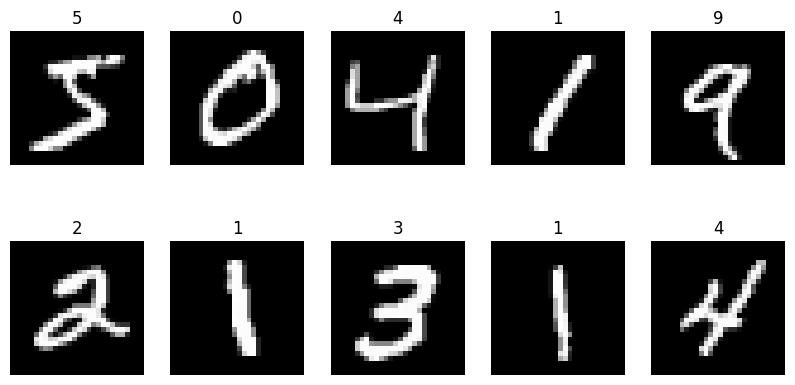

In [19]:

# =========================================
# VISUALIZE SAMPLE IMAGES
# =========================================

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()


In [20]:

# =========================================
# DATA PREPROCESSING
# =========================================

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0


# =========================================
# EARLY STOPPING
# =========================================

early_stop = EarlyStopping(
    patience=3,
    restore_best_weights=True
)


In [21]:


# =========================================
# EXPERIMENT 1
# RELU ACTIVATION
# =========================================

model1 = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

model1.summary()


# =========================================
# COMPILE MODEL 1
# =========================================

model1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# =========================================
# TRAIN MODEL 1
# =========================================

history1 = model1.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9185 - loss: 0.2869 - val_accuracy: 0.9547 - val_loss: 0.1548
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9624 - loss: 0.1283 - val_accuracy: 0.9647 - val_loss: 0.1184
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9746 - loss: 0.0884 - val_accuracy: 0.9694 - val_loss: 0.1068
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9803 - loss: 0.0662 - val_accuracy: 0.9724 - val_loss: 0.0952
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9851 - loss: 0.0501 - val_accuracy: 0.9747 - val_loss: 0.0889
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9882 - loss: 0.0401 - val_accuracy: 0.9738 - val_loss: 0.0900
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9909 - loss: 0.0312 - val_accuracy: 0.9746 - val_loss: 0.0906
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9920 - loss: 0.0250 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9746 - loss: 0.0814

Experiment 1 Results
Test Loss: 0.0813882127404213
Test Accuracy: 0.9746000170707703


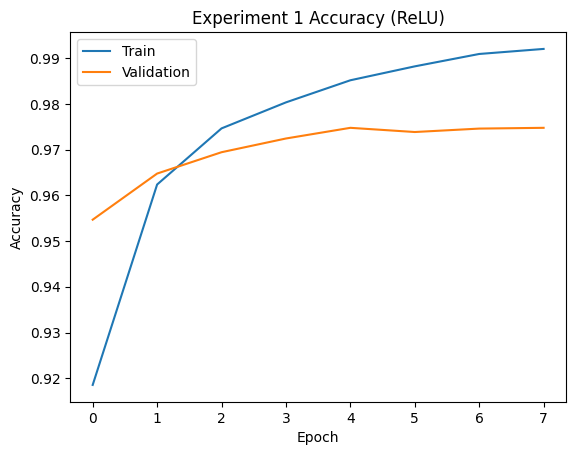

In [22]:

# =========================================
# EVALUATE MODEL 1
# =========================================

test_loss1, test_accuracy1 = model1.evaluate(X_test, y_test)

print("\nExperiment 1 Results")
print("Test Loss:", test_loss1)
print("Test Accuracy:", test_accuracy1)


# =========================================
# ACCURACY GRAPH - EXPERIMENT 1
# =========================================

plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])

plt.title('Experiment 1 Accuracy (ReLU)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

In [23]:

# =========================================
# EXPERIMENT 2
# SIGMOID ACTIVATION
# =========================================

model2 = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(128, activation='sigmoid'),

    Dense(10, activation='softmax')
])

model2.summary()


# =========================================
# COMPILE MODEL 2
# =========================================

model2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# =========================================
# TRAIN MODEL 2
# =========================================

history2 = model2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8850 - loss: 0.4445 - val_accuracy: 0.9312 - val_loss: 0.2439
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9365 - loss: 0.2178 - val_accuracy: 0.9476 - val_loss: 0.1846
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9526 - loss: 0.1635 - val_accuracy: 0.9580 - val_loss: 0.1546


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9283 - loss: 0.2496

Experiment 2 Results
Test Loss: 0.24956369400024414
Test Accuracy: 0.9283000230789185


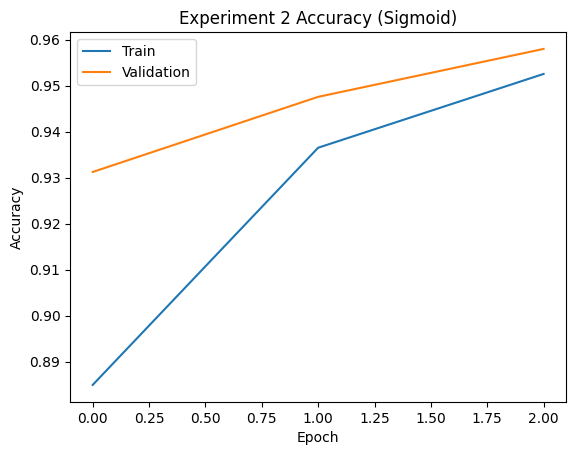

In [24]:


# =========================================
# EVALUATE MODEL 2
# =========================================

test_loss2, test_accuracy2 = model2.evaluate(X_test, y_test)

print("\nExperiment 2 Results")
print("Test Loss:", test_loss2)
print("Test Accuracy:", test_accuracy2)


# =========================================
# ACCURACY GRAPH - EXPERIMENT 2
# =========================================

plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])

plt.title('Experiment 2 Accuracy (Sigmoid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

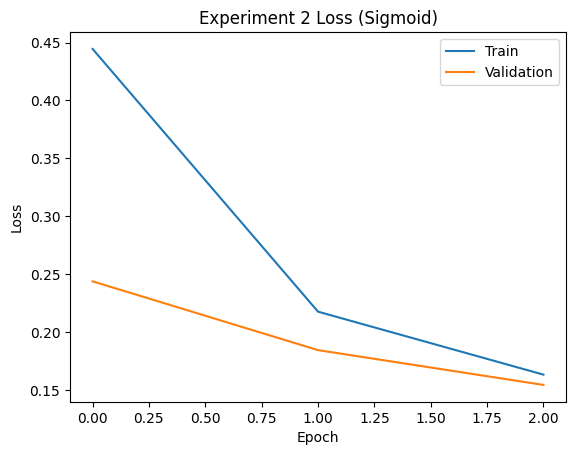

In [25]:

# =========================================
# LOSS GRAPH - EXPERIMENT 2
# =========================================

plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

plt.title('Experiment 2 Loss (Sigmoid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()


In [26]:


# =========================================
# EXPERIMENT 3
# TANH ACTIVATION
# =========================================

model3 = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(128, activation='tanh'),

    Dense(10, activation='softmax')
])

model3.summary()


# =========================================
# COMPILE MODEL 3
# =========================================

model3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# =========================================
# TRAIN MODEL 3
# =========================================

history3 = model3.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)



Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9099 - loss: 0.3110 - val_accuracy: 0.9495 - val_loss: 0.1826
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9542 - loss: 0.1557 - val_accuracy: 0.9629 - val_loss: 0.1353
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9686 - loss: 0.1074 - val_accuracy: 0.9670 - val_loss: 0.1130


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9456 - loss: 0.1831

Experiment 3 Results
Test Loss: 0.18309412896633148
Test Accuracy: 0.9455999732017517


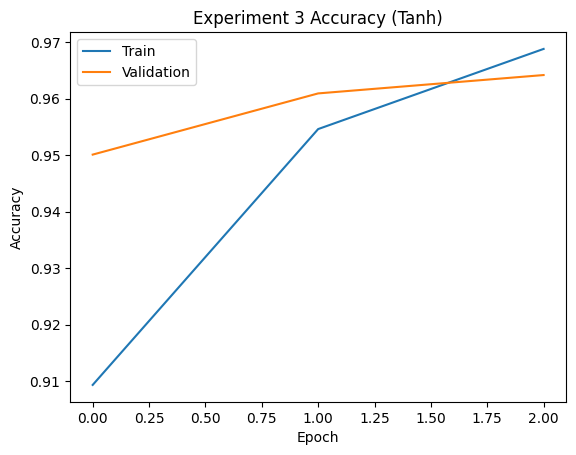

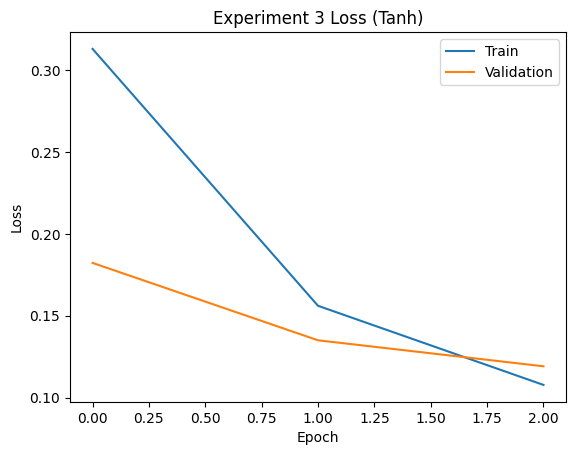

In [16]:


# =========================================
# EVALUATE MODEL 3
# =========================================

test_loss3, test_accuracy3 = model3.evaluate(X_test, y_test)

print("\nExperiment 3 Results")
print("Test Loss:", test_loss3)
print("Test Accuracy:", test_accuracy3)


# =========================================
# ACCURACY GRAPH - EXPERIMENT 3
# =========================================

plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])

plt.title('Experiment 3 Accuracy (Tanh)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()


# =========================================
# LOSS GRAPH - EXPERIMENT 3
# =========================================

plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])

plt.title('Experiment 3 Loss (Tanh)')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()



In [27]:

# =========================================
# FINAL COMPARISON
# =========================================

print("\n========== FINAL COMPARISON ==========")

print(f"ReLU Model Accuracy: {test_accuracy1:.4f}")
print(f"ReLU Model Loss: {test_loss1:.4f}")

print("--------------------------------------")

print(f"Sigmoid Model Accuracy: {test_accuracy2:.4f}")
print(f"Sigmoid Model Loss: {test_loss2:.4f}")

print("--------------------------------------")

print(f"Tanh Model Accuracy: {test_accuracy3:.4f}")
print(f"Tanh Model Loss: {test_loss3:.4f}")


========== FINAL COMPARISON ==========
ReLU Model Accuracy: 0.9746
ReLU Model Loss: 0.0814
--------------------------------------
Sigmoid Model Accuracy: 0.9283
Sigmoid Model Loss: 0.2496
--------------------------------------
Tanh Model Accuracy: 0.9456
Tanh Model Loss: 0.1831
